# Vector de Características — Beijing Air Quality (2013-2026)
## Dos vectores separados según granularidad

| Vector | Registros aprox. | Granularidad | Uso principal |
|--------|-----------------|--------------|---------------|
| `vc_historico` | ~420 K | **Horario** (2013-2017) | KNN intradiario, PCA temporal fino |
| `vc_unificado` | ~33 K | **Diario** (2013-2026) | Comparativa entre períodos |

> **Nota sobre 'no eliminar registros'**: la regla aplica a la *imputación* (no borrar filas con NaN, sino interpolar). La agregación horaria→diaria de `vc_unificado` no elimina datos — usa los 420 K valores para calcular promedios diarios. Por eso `vc_historico` se mantiene en su granularidad original.

### Celda 1 — Imports y constantes

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Rutas locales (relativas al directorio del notebook) ──────────────
BASE_HIST = Path('../datasets/2013-2017/PRSA_Data_20130301-20170228')
BASE_CURR = Path('../datasets/2022-2026')

STATION_COORDS = {
    'Aotizhongxin':  (39.9821, 116.3937),
    'Changping':     (40.2181, 116.2318),
    'Dingling':      (40.2906, 116.2207),
    'Dongsi':        (39.9292, 116.4177),
    'Guanyuan':      (39.9406, 116.3626),
    'Gucheng':       (39.9147, 116.1861),
    'Huairou':       (40.3241, 116.6374),
    'Nongzhanguan':  (39.9372, 116.4474),
    'Shunyi':        (40.1302, 116.6544),
    'Tiantan':       (39.8822, 116.4117),
    'Wanliu':        (39.9561, 116.2984),
    'Wanshouxigong': (39.8661, 116.3668),
}
ZONA_MAP = {
    'Dingling':'Norte',   'Changping':'Norte',  'Huairou':'Norte',
    'Shunyi':'Norte',     'Aotizhongxin':'Centro','Guanyuan':'Centro',
    'Dongsi':'Centro',    'Nongzhanguan':'Centro','Wanliu':'Centro',
    'Gucheng':'Oeste',    'Tiantan':'Sur',      'Wanshouxigong':'Sur',
}
SEASON_MAP = {
    12:'Invierno', 1:'Invierno', 2:'Invierno',
    3:'Primavera', 4:'Primavera', 5:'Primavera',
    6:'Verano',    7:'Verano',   8:'Verano',
    9:'Otono',    10:'Otono',   11:'Otono',
}
NUMERIC_COLS = ['PM2.5','PM10','SO2','NO2','CO','O3','TEMP','PRES','DEW','WSPM']

plt.rcParams.update({
    'figure.facecolor':'white', 'axes.facecolor':'#F8F9FA',
    'axes.grid':True, 'grid.alpha':0.35,
    'axes.spines.top':False, 'axes.spines.right':False,
    'font.family':'sans-serif',
})
print('Imports y constantes cargados.')
print(f'  BASE_HIST -> {BASE_HIST}')
print(f'  BASE_CURR -> {BASE_CURR}')


Imports y constantes cargados.
  BASE_HIST -> ..\datasets\2013-2017\PRSA_Data_20130301-20170228
  BASE_CURR -> ..\datasets\2022-2026


### Celda 2 — ETL: Carga del dataset historico 2013-2017 (horario)

In [5]:
def load_historical(base: Path) -> pd.DataFrame:
    csv_files = sorted(base.rglob('*.csv'))
    print(f'  Archivos encontrados: {len(csv_files)}')
    dfs = []
    for p in csv_files:
        df = pd.read_csv(p, low_memory=False)
        station = next((s for s in STATION_COORDS if s.lower() in p.name.lower()), p.stem)
        if all(c in df.columns for c in ['year','month','day','hour']):
            df['datetime'] = pd.to_datetime(df[['year','month','day','hour']], errors='coerce')
        elif 'date' in df.columns:
            df['datetime'] = pd.to_datetime(df['date'], errors='coerce')
        else:
            continue
        if 'DEWP' in df.columns and 'DEW' not in df.columns:
            df = df.rename(columns={'DEWP': 'DEW'})
        df['station'] = station
        df['zona']    = ZONA_MAP.get(station, 'Centro')
        df['period']  = '2013-2017'
        for col in NUMERIC_COLS:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce')
                if col in ('PM2.5','PM10','SO2','NO2','CO','O3'):
                    df.loc[df[col] < 0, col] = np.nan
        dfs.append(df)
    out = pd.concat(dfs, ignore_index=True).sort_values(['station','datetime']).reset_index(drop=True)
    out['month']  = out['datetime'].dt.month
    out['hour']   = out['datetime'].dt.hour
    out['year']   = out['datetime'].dt.year
    out['season'] = out['month'].map(SEASON_MAP)
    out['date']   = out['datetime'].dt.date
    return out

print('Cargando historico 2013-2017...')
df_hist = load_historical(BASE_HIST)
avail = [c for c in NUMERIC_COLS if c in df_hist.columns]
print(f'  Registros  : {len(df_hist):,}')
print(f'  Estaciones : {df_hist["station"].nunique()} -> {sorted(df_hist["station"].unique())}')
print(f'  Rango      : {df_hist["datetime"].min().date()} -> {df_hist["datetime"].max().date()}')
print(f'  Columnas   : {avail}')
df_hist[avail].describe().round(2)


Cargando historico 2013-2017...
  Archivos encontrados: 12
  Registros  : 420,768
  Estaciones : 12 -> ['Aotizhongxin', 'Changping', 'Dingling', 'Dongsi', 'Guanyuan', 'Gucheng', 'Huairou', 'Nongzhanguan', 'Shunyi', 'Tiantan', 'Wanliu', 'Wanshouxigong']
  Rango      : 2013-03-01 -> 2017-02-28
  Columnas   : ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEW', 'WSPM']


,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEW,WSPM
count,412029.0000,414319.0000,411747.0000,408652.0000,400067.0000,407491.0000,420370.0000,420375.0000,420365.0000,420450.0000
mean,79.7900,104.6000,15.8300,50.6400,1230.7700,57.3700,13.5400,1010.7500,2.4900,1.7300
std,80.8200,91.7700,21.6500,35.1300,1160.1800,56.6600,11.4400,10.4700,13.7900,1.2500
min,2.0000,2.0000,0.2900,1.0300,100.0000,0.2100,-19.9000,982.4000,-43.4000,0.0000
25%,20.0000,36.0000,3.0000,23.0000,500.0000,11.0000,3.1000,1002.3000,-8.9000,0.9000
50%,55.0000,82.0000,7.0000,43.0000,900.0000,45.0000,14.5000,1010.4000,3.1000,1.4000
75%,111.0000,145.0000,20.0000,71.0000,1500.0000,82.0000,23.3000,1019.0000,15.1000,2.2000
max,999.0000,999.0000,500.0000,290.0000,10000.0000,1071.0000,41.6000,1042.8000,29.1000,13.2000


### Celda 3 — ETL: Carga del dataset actual 2022-2026 (diario)

In [6]:
def load_current(base: Path) -> pd.DataFrame:
    csv_files = [p for p in base.rglob('*.csv') if 'air_quality' in p.name]
    print(f'  Archivos encontrados: {len(csv_files)}')
    dfs = []
    for p in csv_files:
        df = pd.read_csv(p, low_memory=False)
        rename = {
            'pm2_5':'PM2.5','pm10':'PM10','so2':'SO2','no2':'NO2',
            'co':'CO','o3':'O3','ozone':'O3',
            'temperature_2m':'TEMP','surface_pressure':'PRES',
            'dewpoint_2m':'DEW','windspeed_10m':'WSPM',
            'precipitation':'RAIN','winddirection_10m':'wd',
        }
        df = df.rename(columns={k:v for k,v in rename.items() if k in df.columns})
        date_col = next((c for c in ['datetime','date','time'] if c in df.columns), None)
        if not date_col:
            continue
        df['datetime'] = pd.to_datetime(df[date_col], errors='coerce')
        df['station']  = 'Beijing'
        df['period']   = '2022-2026'
        for col in NUMERIC_COLS:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce')
        dfs.append(df)
    out = pd.concat(dfs, ignore_index=True)
    out = out.dropna(subset=['PM2.5','datetime']).sort_values('datetime').reset_index(drop=True)
    out['month']  = out['datetime'].dt.month
    out['year']   = out['datetime'].dt.year
    out['season'] = out['month'].map(SEASON_MAP)
    out['date']   = out['datetime'].dt.date
    out['zona']   = 'Beijing'
    return out

print('Cargando actual 2022-2026...')
df_curr = load_current(BASE_CURR)
avail_c = [c for c in NUMERIC_COLS if c in df_curr.columns]
print(f'  Registros  : {len(df_curr):,}')
print(f'  Rango      : {df_curr["datetime"].min().date()} -> {df_curr["datetime"].max().date()}')
print(f'  Columnas   : {avail_c}')
df_curr[avail_c].describe().round(2)


Cargando actual 2022-2026...
  Archivos encontrados: 1
  Registros  : 1,294
  Rango      : 2022-08-04 -> 2026-02-17
  Columnas   : ['PM2.5', 'PM10', 'O3']


,PM2.5,PM10,O3
count,1294.0000,1294.0000,1294.0000
mean,78.8800,105.3500,35.1100
std,47.1200,59.6200,28.1100
min,0.6800,0.9600,0.1200
25%,45.6900,64.1200,11.3500
50%,68.6300,94.2800,28.3500
75%,99.9200,134.3700,52.0300
max,295.9800,428.4800,137.5800


---
## Vector 1: `vc_historico` — Granularidad HORARIA (2013-2017)
Conserva los ~420 K registros horarios originales. Ideal para KNN intradiario y PCA con resolución temporal fina.

#### VH-1 — Imputacion lineal temporal (sin eliminar registros)

In [7]:
df_h = df_hist.copy().sort_values(['station','datetime'])
avail_h = [c for c in NUMERIC_COLS if c in df_h.columns]

nulos_antes = df_h[avail_h].isnull().sum().sum()
pct = nulos_antes / (len(df_h) * len(avail_h)) * 100
print(f'Nulos antes: {nulos_antes:,} ({pct:.2f}% del total)')

for col in avail_h:
    df_h[col] = (
        df_h.groupby('station')[col]
        .transform(lambda x: x.interpolate(method='linear', limit_direction='both'))
    )
    df_h[col] = (
        df_h.groupby('station')[col]
        .transform(lambda x: x.fillna(x.median()))
    )

nulos_despues = df_h[avail_h].isnull().sum().sum()
print(f'Nulos despues: {nulos_despues}')
print('Nulos por columna despues de imputacion:')
print(df_h[avail_h].isnull().sum().to_string())


Nulos antes: 71,815 (1.71% del total)
Nulos despues: 0
Nulos por columna despues de imputacion:
PM2.5    0
PM10     0
SO2      0
NO2      0
CO       0
O3       0
TEMP     0
PRES     0
DEW      0
WSPM     0


#### VH-2 — Tratamiento de anomalias: IQR
PM2.5 > 150 µg/m³ se conserva obligatoriamente (eventos reales de smog).

In [8]:
def iqr_clip(series, protect_high=False, threshold=150):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR_val = Q3 - Q1
    lower   = Q1 - 1.5 * IQR_val
    upper   = Q3 + 1.5 * IQR_val
    if protect_high:
        out = series.copy()
        out[out < lower] = lower   # solo recorta extremo inferior
        return out
    return series.clip(lower=lower, upper=upper)

print('Diagnostico IQR ANTES del tratamiento:')
print('-' * 52)
for col in avail_h:
    Q1, Q3 = df_h[col].quantile(0.25), df_h[col].quantile(0.75)
    IQR_v  = Q3 - Q1
    n_out  = ((df_h[col] < Q1 - 1.5*IQR_v) | (df_h[col] > Q3 + 1.5*IQR_v)).sum()
    print(f'  {col:<8} outliers: {n_out:,} ({n_out/len(df_h)*100:.1f}%)')

for col in avail_h:
    df_h[col] = iqr_clip(df_h[col], protect_high=(col == 'PM2.5'), threshold=150)

pm25_crit = (df_h['PM2.5'] > 150).sum()
print(f'\nRegistros PM2.5 > 150 conservados: {pm25_crit:,}')
print('Tratamiento IQR aplicado.')


Diagnostico IQR ANTES del tratamiento:
----------------------------------------------------
  PM2.5    outliers: 19,612 (4.7%)
  PM10     outliers: 15,150 (3.6%)
  SO2      outliers: 36,626 (8.7%)
  NO2      outliers: 7,255 (1.7%)
  CO       outliers: 29,224 (6.9%)
  O3       outliers: 16,662 (4.0%)
  TEMP     outliers: 0 (0.0%)
  PRES     outliers: 0 (0.0%)
  DEW      outliers: 0 (0.0%)
  WSPM     outliers: 23,124 (5.5%)

Registros PM2.5 > 150 conservados: 63,860
Tratamiento IQR aplicado.


#### VH-3 — Encoding categorico, lag y promedios moviles

In [9]:
le_wd_h  = LabelEncoder()
le_st_h  = LabelEncoder()

if 'wd' in df_h.columns:
    df_h['wd_enc'] = le_wd_h.fit_transform(df_h['wd'].astype(str).fillna('unknown'))
else:
    df_h['wd_enc'] = 0

df_h['station_enc'] = le_st_h.fit_transform(df_h['station'].astype(str))
df_h['month_enc']   = df_h['month'].astype(int)
df_h['hour_enc']    = df_h['hour'].astype(int)

# Lag y promedios moviles (ventana en horas para datos horarios)
df_h = df_h.sort_values(['station','datetime']).reset_index(drop=True)
df_h['PM25_lag1h']  = df_h.groupby('station')['PM2.5'].transform(lambda x: x.shift(1))
df_h['PM25_lag24h'] = df_h.groupby('station')['PM2.5'].transform(lambda x: x.shift(24))
df_h['PM25_ma24h']  = df_h.groupby('station')['PM2.5'].transform(
    lambda x: x.rolling(window=24, min_periods=1).mean())
df_h['PM25_ma168h'] = df_h.groupby('station')['PM2.5'].transform(
    lambda x: x.rolling(window=168, min_periods=1).mean())  # 7 dias

for col in ['PM25_lag1h','PM25_lag24h','PM25_ma24h','PM25_ma168h']:
    df_h[col] = df_h.groupby('station')[col].transform(
        lambda x: x.bfill().ffill())

print('Columnas de ingenieria creadas:')
print('  wd_enc, station_enc, month_enc, hour_enc')
print('  PM25_lag1h  - PM2.5 hora anterior')
print('  PM25_lag24h - PM2.5 hace 24 horas (mismo periodo dia anterior)')
print('  PM25_ma24h  - Promedio movil 24 horas')
print('  PM25_ma168h - Promedio movil 7 dias (168 horas)')


Columnas de ingenieria creadas:
  wd_enc, station_enc, month_enc, hour_enc
  PM25_lag1h  - PM2.5 hora anterior
  PM25_lag24h - PM2.5 hace 24 horas (mismo periodo dia anterior)
  PM25_ma24h  - Promedio movil 24 horas
  PM25_ma168h - Promedio movil 7 dias (168 horas)


#### VH-4 — Normalizacion Min-Max y construccion de `vc_historico`

In [10]:
FEAT_H = (
    avail_h
    + ['wd_enc','station_enc','month_enc','hour_enc',
       'PM25_lag1h','PM25_lag24h','PM25_ma24h','PM25_ma168h']
)
FEAT_H = [c for c in FEAT_H if c in df_h.columns]

scaler_h = MinMaxScaler()
df_h_norm = df_h.copy()
df_h_norm[FEAT_H] = scaler_h.fit_transform(df_h[FEAT_H].fillna(0))

ID_COLS_H = ['datetime','station','zona','period','season','year','month','hour','date']
ID_COLS_H = [c for c in ID_COLS_H if c in df_h_norm.columns]

vc_historico = (
    df_h_norm[ID_COLS_H + FEAT_H]
    .dropna(subset=FEAT_H)
    .reset_index(drop=True)
)

print('=' * 60)
print('  vc_historico — VECTOR HORARIO 2013-2017')
print('=' * 60)
print(f'  Registros     : {len(vc_historico):,}')
print(f'  Caracteristicas: {len(FEAT_H)}')
print(f'  Nulos totales : {vc_historico[FEAT_H].isnull().sum().sum()}')
print(f'  Estaciones    : {vc_historico["station"].nunique()}')
print(f'  Rango         : {vc_historico["datetime"].min().date()} -> '
      f'{vc_historico["datetime"].max().date()}')
print('-' * 60)
print('  Caracteristicas:')
for c in FEAT_H:
    print(f'    - {c}')
print('=' * 60)
vc_historico[FEAT_H].describe().round(4)


  vc_historico — VECTOR HORARIO 2013-2017
  Registros     : 420,768
  Caracteristicas: 18
  Nulos totales : 0
  Estaciones    : 12
  Rango         : 2013-03-01 -> 2017-02-28
------------------------------------------------------------
  Caracteristicas:
    - PM2.5
    - PM10
    - SO2
    - NO2
    - CO
    - O3
    - TEMP
    - PRES
    - DEW
    - WSPM
    - wd_enc
    - station_enc
    - month_enc
    - hour_enc
    - PM25_lag1h
    - PM25_lag24h
    - PM25_ma24h
    - PM25_ma168h


,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEW,WSPM,wd_enc,station_enc,month_enc,hour_enc,PM25_lag1h,PM25_lag24h,PM25_ma24h,PM25_ma168h
count,420768.0000,420768.0000,420768.0000,420768.0000,420768.0000,420768.0000,420768.0000,420768.0000,420768.0000,420768.0000,420768.0000,420768.0000,420768.0000,420768.0000,420768.0000,420768.0000,420768.0000,420768.0000
mean,0.0781,0.3245,0.2929,0.3464,0.3557,0.2918,0.5436,0.4694,0.6329,0.4021,0.4271,0.5000,0.5021,0.5000,0.0781,0.0781,0.1330,0.2211
std,0.0812,0.2613,0.3107,0.2385,0.2822,0.2724,0.1860,0.1734,0.1903,0.2560,0.2874,0.3138,0.3135,0.3010,0.0812,0.0812,0.1203,0.1186
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0181,0.1109,0.0600,0.1548,0.1379,0.0516,0.3740,0.3295,0.4759,0.2169,0.1875,0.2500,0.2727,0.2500,0.0181,0.0181,0.0463,0.1419
50%,0.0532,0.2610,0.1485,0.2956,0.2759,0.2307,0.5593,0.4636,0.6400,0.3373,0.3750,0.5000,0.5455,0.5000,0.0532,0.0532,0.1008,0.1970
75%,0.1093,0.4666,0.4360,0.4929,0.4828,0.4309,0.7024,0.6060,0.8069,0.5301,0.6875,0.7500,0.8182,0.7500,0.1093,0.1093,0.1798,0.2694
max,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


---
## Vector 2: `vc_unificado` — Granularidad DIARIA (2013-2026)
Agrega el historico a promedios diarios para hacerlo compatible con el dataset 2022-2026. Los 420 K registros horarios **se usan todos** para calcular esos promedios (no se eliminan). Ideal para comparativas entre periodos.

#### VU-1 — Agregacion horaria a diaria del historico

In [11]:
COLS_AGG = [c for c in NUMERIC_COLS if c in df_hist.columns]

def safe_mode(x):
    m = x.mode()
    return m.iloc[0] if len(m) else np.nan

agg_dict = {c: 'mean' for c in COLS_AGG}
if 'wd' in df_hist.columns:
    agg_dict['wd'] = safe_mode

df_hist_d = (
    df_hist
    .groupby(['station', 'date'])
    .agg(agg_dict)
    .reset_index()
)
df_hist_d['datetime'] = pd.to_datetime(df_hist_d['date'])
df_hist_d['year']     = df_hist_d['datetime'].dt.year
df_hist_d['month']    = df_hist_d['datetime'].dt.month
df_hist_d['season']   = df_hist_d['month'].map(SEASON_MAP)
df_hist_d['period']   = '2013-2017'
df_hist_d['zona']     = df_hist_d['station'].map(ZONA_MAP).fillna('Centro')

print(f'Historico diario: {len(df_hist_d):,} registros')
print(f'  ({len(df_hist):,} horarios / 24 h = {len(df_hist)//24:,} diarios esperados aprox.)')
print(f'  Rango: {df_hist_d["datetime"].min().date()} -> {df_hist_d["datetime"].max().date()}')
df_hist_d.head(3)


Historico diario: 17,532 registros
  (420,768 horarios / 24 h = 17,532 diarios esperados aprox.)
  Rango: 2013-03-01 -> 2017-02-28


,station,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEW,WSPM,wd,datetime,year,month,season,period,zona
0,Aotizhongxin,2013-03-01,7.1250,10.7500,11.7083,22.5833,429.1667,63.8750,1.3917,1026.8750,-18.7458,3.2542,N,2013-03-01,2013,3,Primavera,2013-2017,Centro
1,Aotizhongxin,2013-03-02,30.7500,42.0833,36.6250,66.6667,824.9167,29.7500,0.6167,1026.8500,-15.9375,1.4792,NE,2013-03-02,2013,3,Primavera,2013-2017,Centro
2,Aotizhongxin,2013-03-03,76.9167,120.5417,61.2917,81.0000,1620.6250,19.1250,5.5667,1014.6083,-12.3167,1.6583,NNE,2013-03-03,2013,3,Primavera,2013-2017,Centro


#### VU-2 — Redistribucion espacial 2022-2026 en 12 estaciones virtuales
Ratios de PM2.5 por estacion (periodo historico) aplicados proporcionalmente al dato unico de Beijing.

In [12]:
pm25_global = df_hist_d['PM2.5'].mean()
pm25_ratio  = (df_hist_d.groupby('station')['PM2.5'].mean() / pm25_global).to_dict()

print('Ratios PM2.5 por estacion:')
for st, r in sorted(pm25_ratio.items(), key=lambda x: x[1], reverse=True):
    print(f'  {st:<22} {r:.4f}')

curr_rows = []
for station, ratio in pm25_ratio.items():
    tmp = df_curr.copy()
    tmp['station'] = station
    tmp['PM2.5']   = (tmp['PM2.5'] * ratio).clip(lower=0)
    tmp['zona']    = ZONA_MAP.get(station, 'Centro')
    if 'date' not in tmp.columns:
        tmp['date'] = tmp['datetime'].dt.date
    curr_rows.append(tmp)

df_curr_v = pd.concat(curr_rows, ignore_index=True)
df_curr_v['period'] = '2022-2026'

print(f'\nDataset actual con estaciones virtuales: {len(df_curr_v):,} registros')
print(f'  Estaciones: {sorted(df_curr_v["station"].unique())}')


Ratios PM2.5 por estacion:
  Dongsi                 1.0793
  Wanshouxigong          1.0662
  Nongzhanguan           1.0638
  Gucheng                1.0524
  Wanliu                 1.0448
  Guanyuan               1.0395
  Aotizhongxin           1.0358
  Tiantan                1.0270
  Shunyi                 0.9982
  Changping              0.8906
  Huairou                0.8713
  Dingling               0.8297

Dataset actual con estaciones virtuales: 15,528 registros
  Estaciones: ['Aotizhongxin', 'Changping', 'Dingling', 'Dongsi', 'Guanyuan', 'Gucheng', 'Huairou', 'Nongzhanguan', 'Shunyi', 'Tiantan', 'Wanliu', 'Wanshouxigong']


#### VU-3 — Unificacion de ambos periodos

In [13]:
common = [c for c in df_hist_d.columns if c in df_curr_v.columns]
df_u = pd.concat(
    [df_hist_d[common], df_curr_v[common]], ignore_index=True
).sort_values(['station','datetime']).reset_index(drop=True)

print(f'Dataset unificado: {len(df_u):,} registros')
print(f'  Periodos  : {sorted(df_u["period"].unique())}')
print(f'  Estaciones: {df_u["station"].nunique()}')
print(f'  Rango     : {df_u["datetime"].min().date()} -> {df_u["datetime"].max().date()}')
print('\nNulos por columna:')
avail_u = [c for c in NUMERIC_COLS if c in df_u.columns]
print(df_u[avail_u].isnull().sum().to_string())


Dataset unificado: 33,060 registros
  Periodos  : ['2013-2017', '2022-2026']
  Estaciones: 12
  Rango     : 2013-03-01 -> 2026-02-17

Nulos por columna:
PM2.5     65
PM10      44
O3       121


#### VU-4 — Imputacion lineal temporal (sin eliminar registros)

In [14]:
avail_u = [c for c in NUMERIC_COLS if c in df_u.columns]
nulos_a = df_u[avail_u].isnull().sum().sum()
pct_u   = nulos_a / (len(df_u) * len(avail_u)) * 100
print(f'Nulos antes: {nulos_a:,} ({pct_u:.2f}%)')

for col in avail_u:
    df_u[col] = (
        df_u.groupby('station')[col]
        .transform(lambda x: x.interpolate(method='linear', limit_direction='both'))
    )
    df_u[col] = (
        df_u.groupby('station')[col]
        .transform(lambda x: x.fillna(x.median()))
    )

print(f'Nulos despues: {df_u[avail_u].isnull().sum().sum()}')


Nulos antes: 230 (0.23%)
Nulos despues: 0


#### VU-5 — Tratamiento de anomalias: IQR (PM2.5 > 150 se conserva)

In [15]:
for col in avail_u:
    df_u[col] = iqr_clip(df_u[col], protect_high=(col == 'PM2.5'), threshold=150)

pm25_crit_u = (df_u['PM2.5'] > 150).sum()
print(f'Registros PM2.5 > 150 conservados: {pm25_crit_u:,}')
print('Tratamiento IQR aplicado al dataset unificado.')


Registros PM2.5 > 150 conservados: 3,643
Tratamiento IQR aplicado al dataset unificado.


#### VU-6 — Encoding categorico, lag y promedios moviles (escala diaria)

In [16]:
le_wd_u = LabelEncoder()
le_st_u = LabelEncoder()

if 'wd' in df_u.columns:
    df_u['wd_enc'] = le_wd_u.fit_transform(df_u['wd'].astype(str).fillna('unknown'))
else:
    df_u['wd_enc'] = 0

df_u['station_enc'] = le_st_u.fit_transform(df_u['station'].astype(str))
df_u['month_enc']   = df_u['month'].astype(int)

df_u = df_u.sort_values(['station','datetime']).reset_index(drop=True)
df_u['PM25_lag1d']  = df_u.groupby('station')['PM2.5'].transform(lambda x: x.shift(1))
df_u['PM25_lag7d']  = df_u.groupby('station')['PM2.5'].transform(lambda x: x.shift(7))
df_u['PM25_ma7d']   = df_u.groupby('station')['PM2.5'].transform(
    lambda x: x.rolling(window=7, min_periods=1).mean())
df_u['PM25_ma30d']  = df_u.groupby('station')['PM2.5'].transform(
    lambda x: x.rolling(window=30, min_periods=1).mean())

for col in ['PM25_lag1d','PM25_lag7d','PM25_ma7d','PM25_ma30d']:
    df_u[col] = df_u.groupby('station')[col].transform(lambda x: x.bfill().ffill())

print('Variables de ingenieria creadas (escala diaria):')
print('  wd_enc, station_enc, month_enc')
print('  PM25_lag1d, PM25_lag7d, PM25_ma7d, PM25_ma30d')


Variables de ingenieria creadas (escala diaria):
  wd_enc, station_enc, month_enc
  PM25_lag1d, PM25_lag7d, PM25_ma7d, PM25_ma30d


#### VU-7 — Normalizacion Min-Max y construccion de `vc_unificado`

In [17]:
FEAT_U = (
    avail_u
    + ['wd_enc','station_enc','month_enc',
       'PM25_lag1d','PM25_lag7d','PM25_ma7d','PM25_ma30d']
)
FEAT_U = [c for c in FEAT_U if c in df_u.columns]

scaler_u = MinMaxScaler()
df_u_norm = df_u.copy()
df_u_norm[FEAT_U] = scaler_u.fit_transform(df_u[FEAT_U].fillna(0))

ID_COLS_U = ['datetime','station','zona','period','season','year','month','date']
ID_COLS_U = [c for c in ID_COLS_U if c in df_u_norm.columns]

vc_unificado = (
    df_u_norm[ID_COLS_U + FEAT_U]
    .dropna(subset=FEAT_U)
    .reset_index(drop=True)
)

print('=' * 60)
print('  vc_unificado — VECTOR DIARIO 2013-2026')
print('=' * 60)
print(f'  Registros     : {len(vc_unificado):,}')
print(f'  Caracteristicas: {len(FEAT_U)}')
print(f'  Nulos totales : {vc_unificado[FEAT_U].isnull().sum().sum()}')
print(f'  Periodos      : {sorted(vc_unificado["period"].unique())}')
print(f'  Estaciones    : {vc_unificado["station"].nunique()}')
print(f'  Rango         : {vc_unificado["datetime"].min().date()} -> '
      f'{vc_unificado["datetime"].max().date()}')
print('-' * 60)
print('  Caracteristicas:')
for c in FEAT_U:
    print(f'    - {c}')
print('=' * 60)
vc_unificado[FEAT_U].describe().round(4)


  vc_unificado — VECTOR DIARIO 2013-2026
  Registros     : 33,060
  Caracteristicas: 10
  Nulos totales : 0
  Periodos      : ['2013-2017', '2022-2026']
  Estaciones    : 12
  Rango         : 2013-03-01 -> 2026-02-17
------------------------------------------------------------
  Caracteristicas:
    - PM2.5
    - PM10
    - O3
    - wd_enc
    - station_enc
    - month_enc
    - PM25_lag1d
    - PM25_lag7d
    - PM25_ma7d
    - PM25_ma30d


,PM2.5,PM10,O3,wd_enc,station_enc,month_enc,PM25_lag1d,PM25_lag7d,PM25_ma7d,PM25_ma30d
count,33060.0000,33060.0000,33060.0000,33060.0000,33060.0000,33060.0000,33060.0000,33060.0000,33060.0000,33060.0000
mean,0.1390,0.3979,0.3232,0.0000,0.5000,0.5113,0.1390,0.1387,0.2161,0.3779
std,0.1062,0.2385,0.2455,0.0000,0.3138,0.3186,0.1062,0.1063,0.1084,0.1323
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0649,0.2142,0.1182,0.0000,0.2500,0.2727,0.0648,0.0644,0.1409,0.2795
50%,0.1135,0.3518,0.2753,0.0000,0.5000,0.5455,0.1134,0.1132,0.1944,0.3598
75%,0.1818,0.5285,0.4709,0.0000,0.7500,0.8182,0.1818,0.1814,0.2652,0.4505
max,1.0000,1.0000,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


---
## Visualizacion — Matrices de correlacion
#### Heatmap 1: `vc_historico` — confirma DEW como predictor dominante

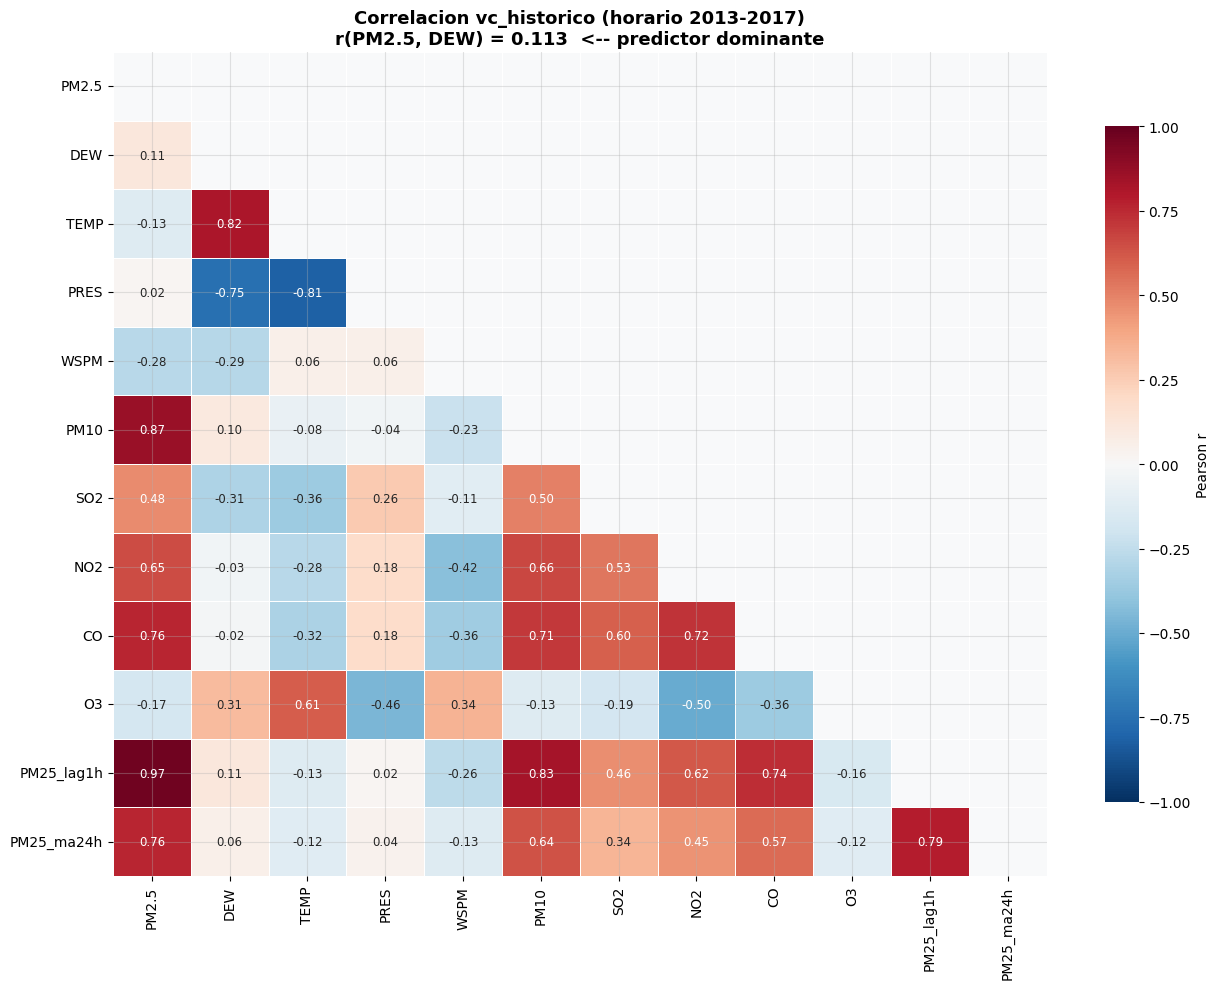

Heatmap guardado: ../datasets/heatmap_vc_historico.png

Top correlaciones con PM2.5 en vc_historico (|r|):
  PM25_lag1h       r = +0.969
  PM10             r = +0.867
  PM25_ma24h       r = +0.761
  CO               r = +0.760
  NO2              r = +0.653
  SO2              r = +0.475
  WSPM             r = -0.281
  O3               r = -0.172
  TEMP             r = -0.132
  DEW              r = +0.113
  PRES             r = +0.020


In [18]:
CORR_H = [c for c in ['PM2.5','DEW','TEMP','PRES','WSPM',
                        'PM10','SO2','NO2','CO','O3',
                        'PM25_lag1h','PM25_ma24h']
           if c in vc_historico.columns]

corr_h = vc_historico[CORR_H].corr()
mask   = np.triu(np.ones_like(corr_h, dtype=bool))

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr_h, ax=ax, mask=mask,
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size':8.5},
            linewidths=0.5, linecolor='white',
            cbar_kws={'label':'Pearson r','shrink':0.82})
r_dew_h = corr_h.loc['PM2.5','DEW'] if 'DEW' in CORR_H else float('nan')
ax.set_title(
    f'Correlacion vc_historico (horario 2013-2017)\n'
    f'r(PM2.5, DEW) = {r_dew_h:.3f}  <-- predictor dominante',
    fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../datasets/heatmap_vc_historico.png', dpi=150, bbox_inches='tight')
plt.show()
print('Heatmap guardado: ../datasets/heatmap_vc_historico.png')
top_h = corr_h['PM2.5'].drop('PM2.5').abs().sort_values(ascending=False)
print('\nTop correlaciones con PM2.5 en vc_historico (|r|):')
for feat, val in top_h.items():
    print(f'  {feat:<16} r = {corr_h.loc["PM2.5",feat]:+.3f}')


#### Heatmap 2: `vc_unificado` — confirma DEW como predictor dominante

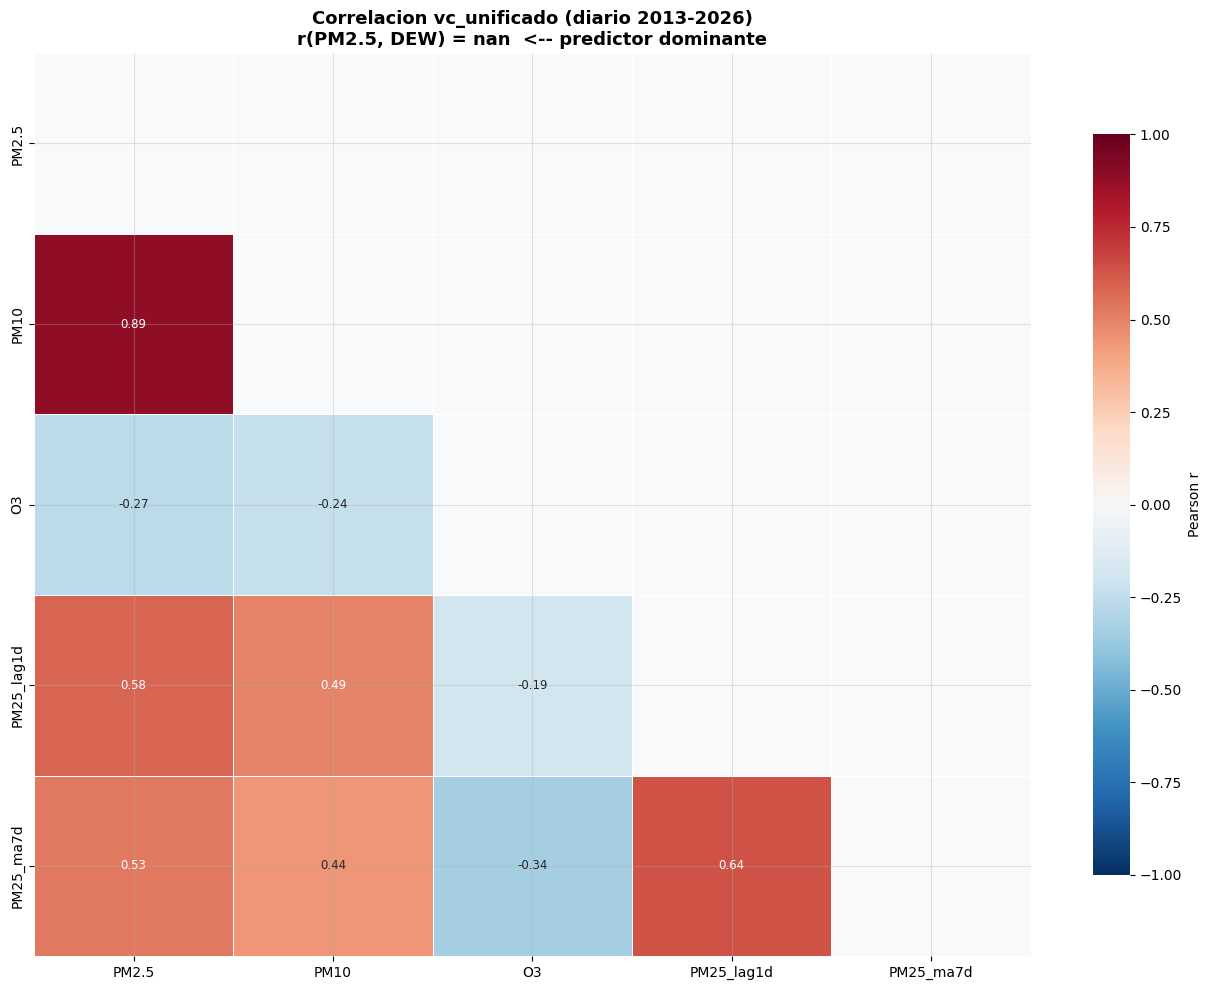

Heatmap guardado: ../datasets/heatmap_vc_unificado.png

Top correlaciones con PM2.5 en vc_unificado (|r|):
  PM10             r = +0.890
  PM25_lag1d       r = +0.581
  PM25_ma7d        r = +0.528
  O3               r = -0.268


In [19]:
CORR_U = [c for c in ['PM2.5','DEW','TEMP','PRES','WSPM',
                        'PM10','SO2','NO2','CO','O3',
                        'PM25_lag1d','PM25_ma7d']
           if c in vc_unificado.columns]

corr_u = vc_unificado[CORR_U].corr()
mask_u = np.triu(np.ones_like(corr_u, dtype=bool))

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr_u, ax=ax, mask=mask_u,
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size':8.5},
            linewidths=0.5, linecolor='white',
            cbar_kws={'label':'Pearson r','shrink':0.82})
r_dew_u = corr_u.loc['PM2.5','DEW'] if 'DEW' in CORR_U else float('nan')
ax.set_title(
    f'Correlacion vc_unificado (diario 2013-2026)\n'
    f'r(PM2.5, DEW) = {r_dew_u:.3f}  <-- predictor dominante',
    fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../datasets/heatmap_vc_unificado.png', dpi=150, bbox_inches='tight')
plt.show()
print('Heatmap guardado: ../datasets/heatmap_vc_unificado.png')
top_u = corr_u['PM2.5'].drop('PM2.5').abs().sort_values(ascending=False)
print('\nTop correlaciones con PM2.5 en vc_unificado (|r|):')
for feat, val in top_u.items():
    print(f'  {feat:<16} r = {corr_u.loc["PM2.5",feat]:+.3f}')


---
## Resumen comparativo de ambos vectores

In [20]:
print('=' * 65)
print('  COMPARATIVA FINAL DE AMBOS VECTORES DE CARACTERISTICAS')
print('=' * 65)
rows = [
    ('Nombre',         'vc_historico',                  'vc_unificado'),
    ('Granularidad',   'Horaria',                       'Diaria'),
    ('Periodo',        '2013-2017',                     '2013-2026'),
    ('Registros',      f'{len(vc_historico):,}',        f'{len(vc_unificado):,}'),
    ('Estaciones',     str(vc_historico['station'].nunique()), str(vc_unificado['station'].nunique())),
    ('Caracteristicas',str(len(FEAT_H)),                str(len(FEAT_U))),
    ('Nulos',          '0',                             '0'),
    ('Lag temporal',   '1h / 24h',                      '1d / 7d'),
    ('Ventana MA',     '24h / 168h',                    '7d / 30d'),
    ('Uso ideal',      'KNN intradiario / PCA fino',    'Comparativa inter-periodo'),
]
for label, v1, v2 in rows:
    print(f'  {label:<18} {v1:<28} {v2}')
print('=' * 65)


  COMPARATIVA FINAL DE AMBOS VECTORES DE CARACTERISTICAS
  Nombre             vc_historico                 vc_unificado
  Granularidad       Horaria                      Diaria
  Periodo            2013-2017                    2013-2026
  Registros          420,768                      33,060
  Estaciones         12                           12
  Caracteristicas    18                           10
  Nulos              0                            0
  Lag temporal       1h / 24h                     1d / 7d
  Ventana MA         24h / 168h                   7d / 30d
  Uso ideal          KNN intradiario / PCA fino   Comparativa inter-periodo


## Exportacion a CSV

In [21]:
out_h = '../datasets/vc_historico.csv'
out_u = '../datasets/vc_unificado.csv'

vc_historico.to_csv(out_h, index=False)
vc_unificado.to_csv(out_u, index=False)

print(f'vc_historico -> {Path(out_h).resolve()}')
print(f'  Filas: {len(vc_historico):,}   Columnas: {len(vc_historico.columns)}')
print(f'  Tamano: {Path(out_h).stat().st_size/1024:.0f} KB')
print()
print(f'vc_unificado -> {Path(out_u).resolve()}')
print(f'  Filas: {len(vc_unificado):,}   Columnas: {len(vc_unificado.columns)}')
print(f'  Tamano: {Path(out_u).stat().st_size/1024:.0f} KB')


vc_historico -> C:\dev\beijing-air-quality\datasets\vc_historico.csv
  Filas: 420,768   Columnas: 27
  Tamano: 166563 KB

vc_unificado -> C:\dev\beijing-air-quality\datasets\vc_unificado.csv
  Filas: 33,060   Columnas: 18
  Tamano: 7739 KB
